# Feature Scaling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/data-preprocessing/feature-scaling/notes.ipynb)

*A general-purpose preprocessing step, used across almost every algorithm module in this repo — putting features
on comparable scales before fitting a model.*


## 1. Why scale features at all?

Imagine two features in a model: `TV budget` (values in the thousands) and `Social Media budget` (values in
single digits, because it's tracked in millions). Left unscaled:

- A gradient-descent-based model compensates for the mismatch by learning a tiny weight for TV and a huge weight
  for Social Media — which makes the *raw* weights incomparable and can slow convergence.
- A distance-based model (k-means, KNN) lets whichever feature has the larger raw range dominate the distance
  calculation, regardless of which feature actually matters more.

Scaling puts every feature on the same footing before either of those becomes a problem.


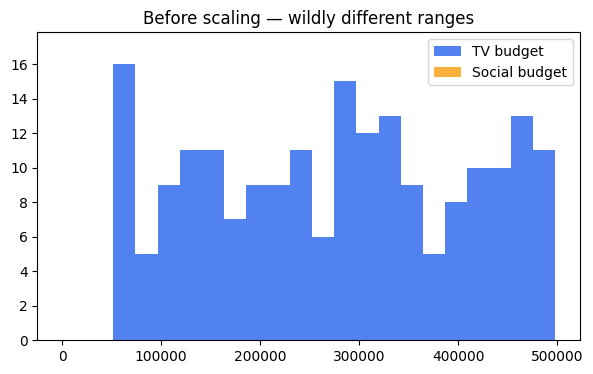

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
tv_budget = rng.uniform(50_000, 500_000, 200)
social_budget = rng.uniform(1, 30, 200)

plt.figure(figsize=(7, 4))
plt.hist(tv_budget, bins=20, color="#2563EB", alpha=0.8, label="TV budget")
plt.hist(social_budget, bins=20, color="#F59E0B", alpha=0.8, label="Social budget")
plt.title("Before scaling — wildly different ranges")
plt.legend()
plt.show()

## 2. Standardization (Z-score)

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

Centers every feature at mean 0 with standard deviation 1. This is the safe default for most models.


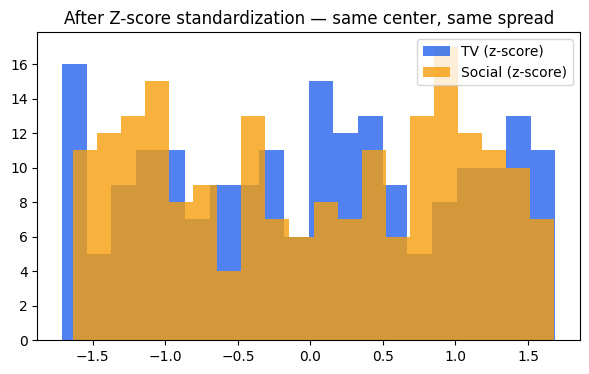

TV mean/std after scaling:     -0.0000 / 1.0000
Social mean/std after scaling: -0.0000 / 1.0000


In [2]:
z_tv = (tv_budget - tv_budget.mean()) / tv_budget.std()
z_social = (social_budget - social_budget.mean()) / social_budget.std()

plt.figure(figsize=(7, 4))
plt.hist(z_tv, bins=20, color="#2563EB", alpha=0.8, label="TV (z-score)")
plt.hist(z_social, bins=20, color="#F59E0B", alpha=0.8, label="Social (z-score)")
plt.title("After Z-score standardization — same center, same spread")
plt.legend()
plt.show()

print(f"TV mean/std after scaling:     {z_tv.mean():.4f} / {z_tv.std():.4f}")
print(f"Social mean/std after scaling: {z_social.mean():.4f} / {z_social.std():.4f}")

## 3. Min-Max normalization

$$
x_{scaled} = \frac{x - \min}{\max - \min}
$$

Squeezes every value into $[0, 1]$ by construction — proof: at $x = \min$, the result is 0; at $x = \max$, the
result is 1; everything else lands in between.


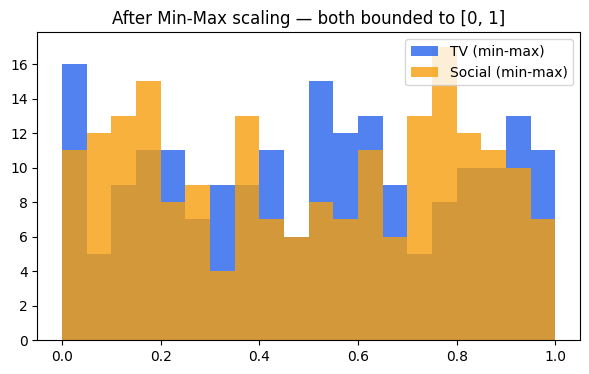

In [3]:
mm_tv = (tv_budget - tv_budget.min()) / (tv_budget.max() - tv_budget.min())
mm_social = (social_budget - social_budget.min()) / (social_budget.max() - social_budget.min())

plt.figure(figsize=(7, 4))
plt.hist(mm_tv, bins=20, color="#2563EB", alpha=0.8, label="TV (min-max)")
plt.hist(mm_social, bins=20, color="#F59E0B", alpha=0.8, label="Social (min-max)")
plt.title("After Min-Max scaling — both bounded to [0, 1]")
plt.legend()
plt.show()

## 4. The outlier problem with Min-Max

> **Critical limitation:** if a feature has one extreme outlier, that outlier *becomes* the max. Every other,
> perfectly normal value then gets squashed into a tiny band near 0 (e.g. $[0.0, 0.18]$), losing most of the
> real variance in the feature.


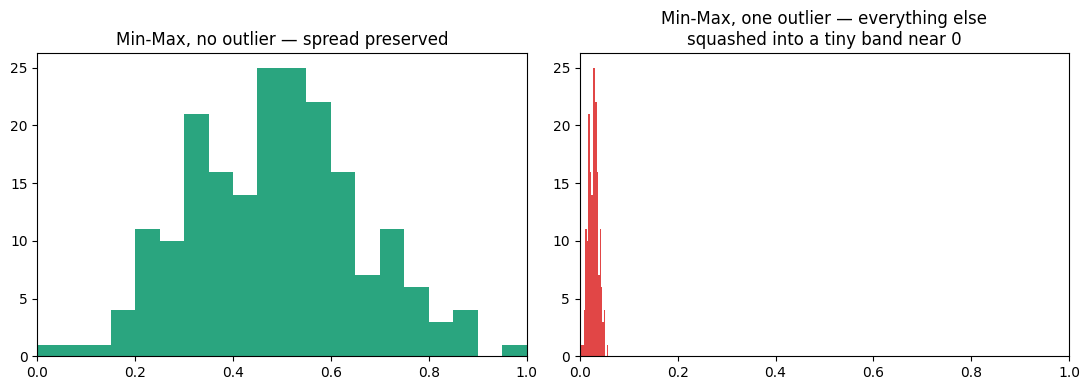

Range without outlier: [0.00, 1.00]
Range of the 199 normal points, with one outlier present: [0.000, 0.058]


In [4]:
normal_vals = rng.normal(50, 5, 199)
with_outlier = np.append(normal_vals, 500)  # one extreme value

mm_normal = (normal_vals - normal_vals.min()) / (normal_vals.max() - normal_vals.min())
mm_with_outlier = (with_outlier - with_outlier.min()) / (with_outlier.max() - with_outlier.min())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(mm_normal, bins=20, color="#059669", alpha=0.85)
axes[0].set_title("Min-Max, no outlier — spread preserved")
axes[0].set_xlim(0, 1)

axes[1].hist(mm_with_outlier[:-1], bins=20, color="#DC2626", alpha=0.85)
axes[1].set_title("Min-Max, one outlier — everything else\nsquashed into a tiny band near 0")
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()
print(f"Range without outlier: [{mm_normal.min():.2f}, {mm_normal.max():.2f}]")
print(f"Range of the 199 normal points, with one outlier present: [{mm_with_outlier[:-1].min():.3f}, {mm_with_outlier[:-1].max():.3f}]")

Z-score standardization is more robust here, since it's built from the mean and standard deviation rather than
the raw min/max — one outlier moves those far less than it moves the range.


## 5. Which one, and when

| | Standardization (Z-score) | Min-Max |
|---|---|---|
| Result | mean 0, std 1, unbounded range | bounded to $[0, 1]$ |
| Outlier sensitivity | low | high — one extreme value compresses everything else |
| Good default for | gradient-descent models (linear/logistic regression, neural nets), distance-based models (k-means, KNN, PCA) | when a bounded range is specifically required (e.g. some neural net input layers, image pixel values) |
| Not needed for | tree-based models (decision trees, random forests, gradient boosting) — splits don't care about feature scale | |

**Rule of thumb:** always handle outliers first (see [EDA](../eda/notes.ipynb)), then reach for Min-Max only when
something downstream specifically needs a $[0,1]$ range; standardization is the safer everyday default.

**In practice:** fit the scaler on the training set only, then use that same fitted scaler to transform the test
set (`scaler.fit_transform(X_train)`, `scaler.transform(X_test)`) — fitting on the full dataset leaks information
about the test set into training.
